# Reverse-mode gradient cost: gradsolve against diffrax

This notebook times one reverse-mode gradient through an ensemble solve for gradsolve and for
diffrax on the same problem, at the same achieved accuracy, on whatever hardware runs it. It uses
only `gradsolve`, the `diffrax` extra, scipy, pandas and matplotlib.

**Problem.** A Lorenz ensemble (sigma = 10, beta = 8/3, rho swept over [0, 21], y0 = (1, 0, 0),
t in [0, 1]), the configuration used by the published GPU ODE benchmarks. The gradient is that of
`sum(y_final**2)` with respect to each trajectory's rho.

**Arms.**
- *gradsolve fused* (`engine="warp_replay"`): the fused Warp kernel records the accepted step
  sizes, a pure-JAX scan replays them.
- *gradsolve general* (`engine="tsit5_replay"`): the same record-and-replay for any user
  `f_jax`, with no fused kernel.
- *diffrax*: Tsit5, a PID step controller and `RecursiveCheckpointAdjoint`, configured so that it
  is timed at its fastest setting rather than at a default. An untimed probe solve measures its
  step counts, the step budget is sized from them, and three checkpoint settings are timed (the
  budget sized to the attempts with checkpoints equal to it, 1.5 times the attempts, and the
  library default); the fastest is the one reported.

**Protocol.** Every arm is timed the same way: `jax.jit(jax.grad(...))`, one untimed warm-up call,
then the best of several timed calls with `block_until_ready`. Accuracy is the median relative
error of `y_final` against a scipy DOP853 reference at rtol 1e-11, which belongs to neither arm.
Speedups are read at matched accuracy: diffrax's cost is interpolated (log-log) onto the error
gradsolve achieved, never compared at the same requested tolerance. For gradsolve the one-off
cost of recording the mesh is reported separately; it is paid once per parameter point.

**Run it.** The defaults (128 trajectories, CPU) finish in a few minutes on a laptop. Set the
environment variables below before starting the kernel to change the sizes, tolerances, repeats or
device, or run the same code from the command line:

```bash
python benchmarks/reverse_mode_vs_diffrax.py --n 2048 32768 --device cuda --repeats 5
```

The committed outputs below come from a run on one NVIDIA H200 (the hardware line is printed by
the first cell).


In [1]:
import os, pathlib, subprocess, sys

REPO = pathlib.Path.cwd()
while not (REPO / "benchmarks" / "reverse_mode_vs_diffrax.py").exists():
    REPO = REPO.parent
sys.path.insert(0, str(REPO / "benchmarks"))

import jax
import pandas as pd
import reverse_mode_vs_diffrax as bench

NS = [int(x) for x in os.environ.get("GRADSOLVE_BENCH_NS", "128").split()]
RTOLS = [float(x) for x in os.environ.get("GRADSOLVE_BENCH_RTOLS", "1e-3 1e-4 1e-5 1e-6 1e-7 1e-8").split()]
REPEATS = int(os.environ.get("GRADSOLVE_BENCH_REPEATS", "3"))
DEVICE = os.environ.get("GRADSOLVE_BENCH_DEVICE", "cpu")

print("jax", jax.__version__, "devices:", jax.devices())
try:
    print("GPU:", subprocess.run(["nvidia-smi", "--query-gpu=name,driver_version", "--format=csv,noheader"],
                                 capture_output=True, text=True, timeout=10).stdout.strip().splitlines()[0])
except Exception:
    print("GPU: none visible")
print(f"ensemble sizes {NS}, tolerances {RTOLS}, best of {REPEATS}, device {DEVICE}")


jax 0.10.2 devices: [CudaDevice(id=0)]
GPU: NVIDIA H200 NVL, 610.57.04
ensemble sizes [128, 2048, 32768], tolerances [0.001, 0.0001, 1e-05, 1e-06, 1e-07, 1e-08], best of 5, device cuda


In [2]:
rows = bench.run(NS, RTOLS, REPEATS, DEVICE)


n = 128: computing the scipy reference for 128 trajectories ...


Warp 1.15.0 initialized:
   CUDA Toolkit 12.9, Driver 13.3
   Devices:
     "cpu"      : "x86_64"
     "cuda:0"   : "NVIDIA H200 NVL" (140 GiB, sm_90, mempool enabled)
   Kernel cache:
     /data/aspuriom/gradsolve-bench/.cache/warp/1.15.0
Module gradsolve.warp._warp_kernel 244dd66 load on device 'cuda:0' took 7.28 ms  (cached)


  n=128 rtol=1e-03 gradsolve fused        0.650 ms/gradient  err 1.04e-03  (record 0.05 s)


  n=128 rtol=1e-03 gradsolve general      0.783 ms/gradient  err 1.04e-03  (record 0.27 s)


  n=128 rtol=1e-03 diffrax                8.697 ms/gradient  err 1.06e-03  (checkpoints == max_steps == attempts + 1, max_steps 19)


...

  n=32768 rtol=1e-07 gradsolve general      6.588 ms/gradient  err 1.96e-08  (record 0.33 s)


  n=32768 rtol=1e-07 diffrax               48.994 ms/gradient  err 2.08e-08  (checkpoints == max_steps == attempts + 1, max_steps 85)


  n=32768 rtol=1e-08 gradsolve fused        8.342 ms/gradient  err 1.01e-09  (record 0.18 s)


  n=32768 rtol=1e-08 gradsolve general     10.309 ms/gradient  err 1.01e-09  (record 0.34 s)


  n=32768 rtol=1e-08 diffrax               74.665 ms/gradient  err 1.03e-09  (checkpoints == max_steps == attempts + 1, max_steps 130)


In [3]:
table = pd.DataFrame(rows)[["n", "rtol", "arm", "err", "ms", "record_s", "setting"]]
table.columns = ["n", "rtol", "arm", "achieved error (median rel.)", "ms per gradient", "record (s)", "diffrax setting"]
table


,n,rtol,arm,achieved error (median rel.),ms per gradient,record (s),diffrax setting
0,128,1.000000e-03,gradsolve fused,1.038171e-03,0.649830,0.048222,
1,128,1.000000e-03,gradsolve general,1.038171e-03,0.782801,0.265660,
2,128,1.000000e-03,diffrax,1.062241e-03,8.696956,NaN,checkpoints == max_steps == attempts + 1
3,128,1.000000e-04,gradsolve fused,1.502543e-04,0.940188,0.003216,
4,128,1.000000e-04,gradsolve general,1.502543e-04,1.071517,0.263336,
5,128,1.000000e-04,diffrax,1.487815e-04,11.718443,NaN,checkpoints == max_steps == attempts + 1
6,128,1.000000e-05,gradsolve fused,6.239053e-06,1.394179,0.003319,
7,128,1.000000e-05,gradsolve general,6.239053e-06,1.861729,0.255771,
8,128,1.000000e-05,diffrax,6.438152e-06,17.445864,NaN,checkpoints == max_steps == attempts + 1
9,128,1.000000e-06,gradsolve fused,3.155209e-07,2.229432,0.003041,


In [4]:
speed = pd.DataFrame(bench.matched_speedups(rows))
speed.columns = ["n", "rtol", "arm", "achieved error", "ms per gradient", "speedup over diffrax at matched accuracy"]
speed


,n,rtol,arm,achieved error,ms per gradient,speedup over diffrax at matched accuracy
0,128,1.000000e-03,gradsolve fused,1.038171e-03,0.649830,13.430050
1,128,1.000000e-03,gradsolve general,1.038171e-03,0.782801,11.148745
2,128,1.000000e-04,gradsolve fused,1.502543e-04,0.940188,12.445326
3,128,1.000000e-04,gradsolve general,1.502543e-04,1.071517,10.919981
4,128,1.000000e-05,gradsolve fused,6.239053e-06,1.394179,12.576066
5,128,1.000000e-05,gradsolve general,6.239053e-06,1.861729,9.417744
6,128,1.000000e-06,gradsolve fused,3.155209e-07,2.229432,12.624543
7,128,1.000000e-06,gradsolve general,3.155209e-07,2.805030,10.033960
8,128,1.000000e-07,gradsolve fused,1.953271e-08,3.430185,12.423916
9,128,1.000000e-07,gradsolve general,1.953270e-08,4.402837,9.679289


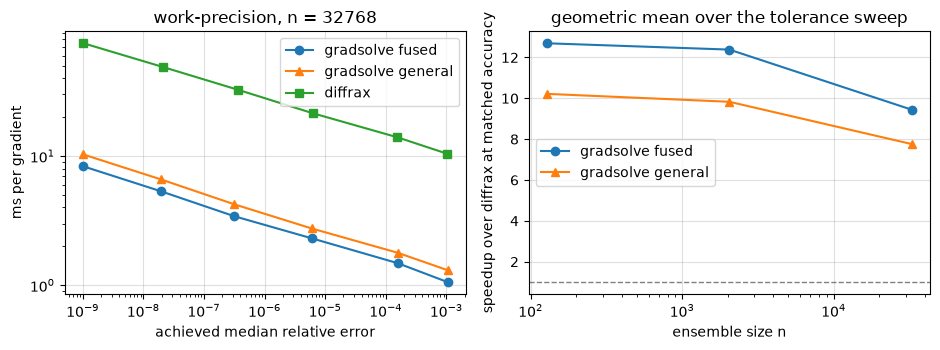

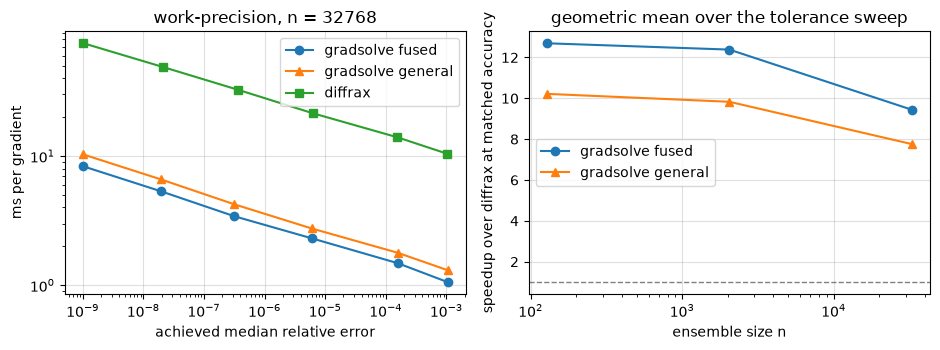

In [5]:
fig = bench.plot(rows)
fig


## Reading the result

The left panel is a work-precision diagram: cost against the accuracy actually reached. A method
that is fast because it is inaccurate sits to the right, not below. The right panel reads the
speedup at matched accuracy for each ensemble size, as the geometric mean over the tolerances
where gradsolve's error falls inside diffrax's measured range.

Two things to keep in mind. The timed number is the cost of one gradient at a fixed parameter
point; gradsolve's closure records the step mesh once (the "record" column) and is valid near
that point, so a fit that moves far re-records. And the diffrax arm is timed at the best of three
checkpoint settings on a step budget sized from its own step counts; a default configuration
would be slower, which is why it is not the one reported.
